In [1]:
from feature_extraction import get_feature
from cnn import run_pipeline

Backend: GPU (CuPy)


In [2]:
stft = get_feature("stft")

In [3]:
train_x, train_y, train_s = stft["train"]
val_x,   val_y,   val_s   = stft["val"]
test_x,  test_y,  test_s  = stft["test"]

Using device: GPU (CuPy)
train_x shape: (15038, 1, 257, 313)
Number of classes: 2
CNNModel(
  (features)
    Conv2d
    BatchNorm2d
    ReLU
    MaxPool2d
    Conv2d
    BatchNorm2d
    ReLU
    MaxPool2d
    Conv2d
    BatchNorm2d
    ReLU
    AdaptiveAvgPool2d
  (classifier)
    Flatten
    Linear
    ReLU
    Dropout
    Linear
    ReLU
    Dropout
    Linear
)

Epoch [1/50]
  Train — Loss: 0.5831  Acc: 0.7417
  Val   — Loss: 0.4474  Acc: 0.8197
  ✓ Best model saved → best_stft_model.npz

Epoch [2/50]
  Train — Loss: 0.4103  Acc: 0.8677
  Val   — Loss: 0.3949  Acc: 0.9063
  ✓ Best model saved → best_stft_model.npz

Epoch [3/50]
  Train — Loss: 0.3778  Acc: 0.8899
  Val   — Loss: 0.5026  Acc: 0.7567

Epoch [4/50]
  Train — Loss: 0.3650  Acc: 0.8985
  Val   — Loss: 0.3527  Acc: 0.9165
  ✓ Best model saved → best_stft_model.npz

Epoch [5/50]
  Train — Loss: 0.3505  Acc: 0.9090
  Val   — Loss: 0.4533  Acc: 0.8327

Epoch [6/50]
  Train — Loss: 0.3444  Acc: 0.9114
  Val   — Loss: 0.7434  

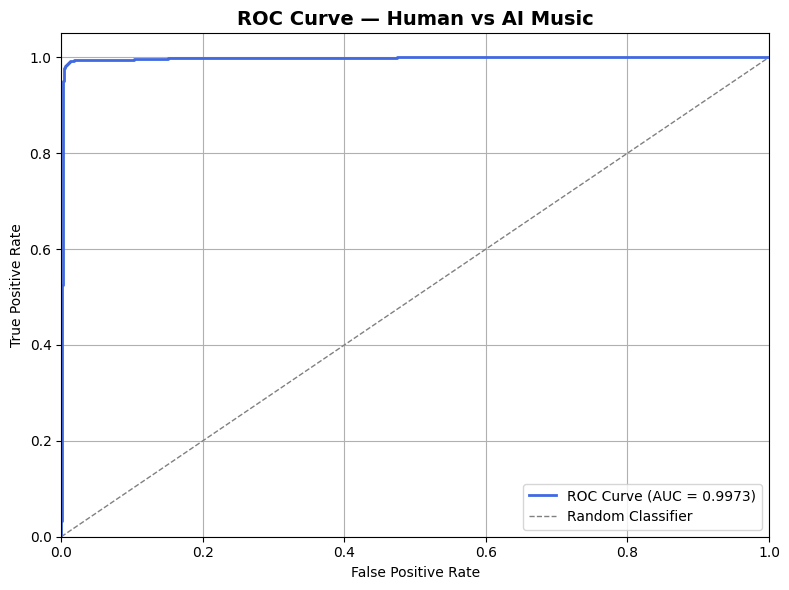

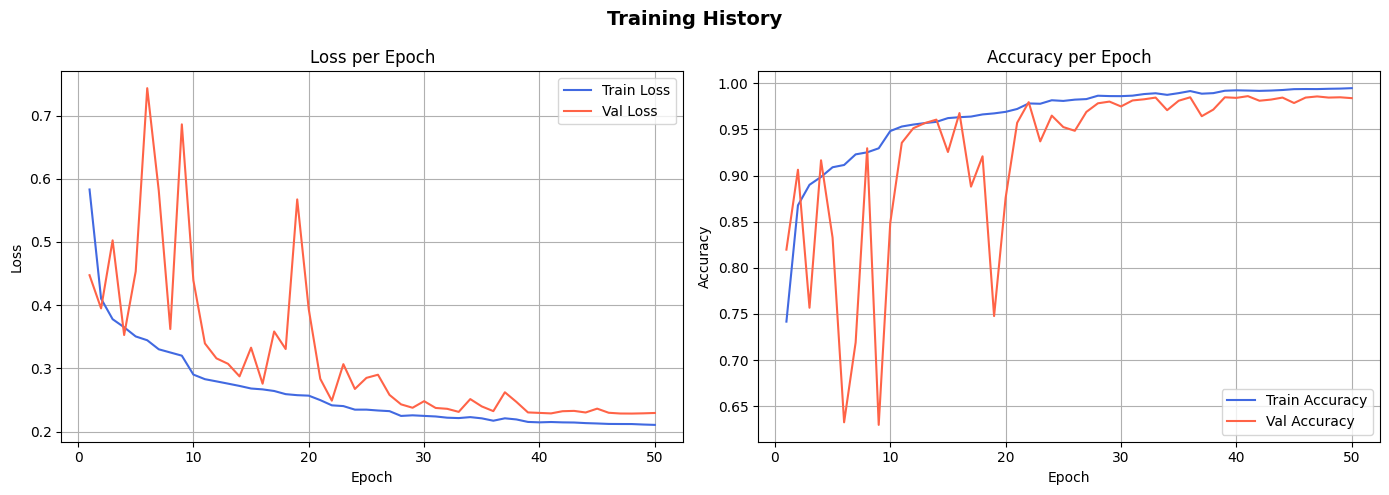

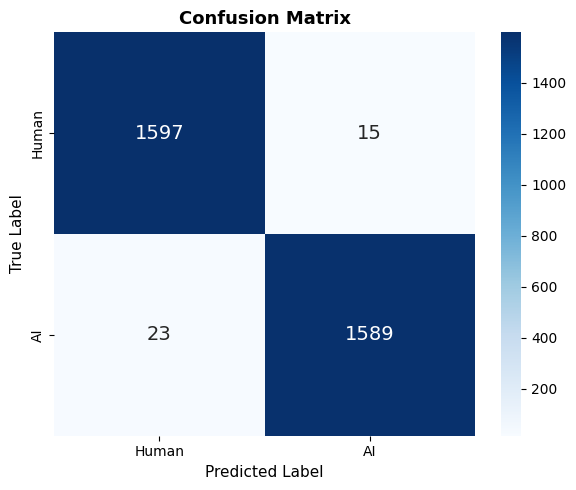

In [4]:
run_pipeline(
    train_x, train_y,
    val_x,   val_y,
    test_x,  test_y,
    labels     = ["Human", "AI"],
    scenario   = "stft",
    train_s    = train_s,
    val_s      = val_s,
    test_s     = test_s,
)

In [5]:
import psutil
import os
import numpy as np
import gc

def memory_report(label=""):
    process = psutil.Process(os.getpid())
    ram_used = process.memory_info().rss / 1024**3
    ram_total = psutil.virtual_memory().total / 1024**3
    ram_avail = psutil.virtual_memory().available / 1024**3
    print(f"\n{'='*40}")
    print(f"[{label}]")
    print(f"  RAM used      : {ram_used:.2f} GB")
    print(f"  RAM available : {ram_avail:.2f} GB")
    print(f"  RAM total     : {ram_total:.2f} GB")
    print(f"{'='*40}")

# Run this BEFORE loading anything
memory_report("baseline")

stft = get_feature("stft")
memory_report("after get_feature")

train_x, train_y, train_s = stft["train"]
val_x,   val_y,   val_s   = stft["val"]
test_x,  test_y,  test_s  = stft["test"]
memory_report("after split")

print(f"\ntrain_x shape : {train_x.shape}")
print(f"train_x dtype : {train_x.dtype}")
print(f"train_x size  : {train_x.nbytes / 1024**3:.2f} GB")
print(f"val_x size    : {val_x.nbytes / 1024**3:.2f} GB")
print(f"test_x size   : {test_x.nbytes / 1024**3:.2f} GB")

_ = gc.collect()
memory_report("after gc")


[baseline]
  RAM used      : 6.94 GB
  RAM available : 2.07 GB
  RAM total     : 15.19 GB

[after get_feature]
  RAM used      : 6.94 GB
  RAM available : 2.06 GB
  RAM total     : 15.19 GB

[after split]
  RAM used      : 6.94 GB
  RAM available : 2.06 GB
  RAM total     : 15.19 GB

train_x shape : (15038, 257, 313, 1)
train_x dtype : float32
train_x size  : 4.51 GB
val_x size    : 0.97 GB
test_x size   : 0.97 GB

[after gc]
  RAM used      : 7.07 GB
  RAM available : 1.89 GB
  RAM total     : 15.19 GB
